In [1]:
import itertools
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error as mse
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

Define the fitting parameters

In [2]:
params = ['Bp', 'n']
labels = ['B', 'n']
units = ['mA*K$^{-3/n}$/cm$^2$', 'unitless']
param_ranges = [np.logspace(1, 3, 20), np.linspace(1, 2, 20)]

combinations = list(itertools.product(*param_ranges))
nb_params = len(params)

Get and plot the "observed" data

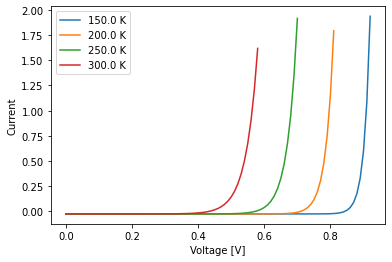

In [3]:
def compute_ID(ec, combination):
    J_L = -0.03 # treat as fixed for now
    V = ec['V']
    T = ec['T']
    V_th = 8.61733e-5 * T # thermal voltage, kT/q
    n = combination[1]
    Bp = combination[0]
    J0 = Bp*T**(3/n)*np.exp(-1.2/V_th/n)
    return J_L + J0*(np.exp(V/V_th/n)-1)

V = np.arange(0, 1.0, 0.01)
T = [float(t) for t in np.arange(150, 301, 50)]

true_combination = [258, 1.36]

data = []
for t in T:
    J = [compute_ID({'V':v,'T':t}, true_combination) for v in V]
    J = [j for j in J if not j > 2.0]
    data.append([V[:len(J)], t, J])

data = pd.DataFrame.from_records(data=data,columns=['V', 'T', 'J'])

fig, ax = plt.subplots()
for idx in data.index:
    ax.plot(data.loc[idx, 'V'], data.loc[idx, 'J'], label=f"{data.loc[idx, 'T']} K")
plt.legend()
plt.xlabel('Voltage [V]')
plt.ylabel('Current')
plt.show()

Bayesian Inference

In [4]:
bpe = pd.DataFrame(index=pd.MultiIndex.from_tuples(combinations, names=params))

bpe['Prior'] = 1/len(combinations) #assume that all the are combinations equiprobable
bpe['Error'] = np.nan

for cb in combinations:
    err = []

    for idx in data.index: #calculate the error between the modeled and observed IV curves at every temperature
        i_model = [compute_ID({'V':v,'T':data.loc[idx, 'T']}, cb) for v in data.loc[idx, 'V']]
        err.append(mse(i_model, data.loc[idx, 'J']))

    bpe.loc[cb, 'Error'] = np.sum(err)

bpe['Likelihood'] = np.exp(-bpe['Error']) #assuming an exponential probability distribution

bpe['Posterior'] = bpe['Prior']*bpe['Likelihood']/np.sum(bpe['Prior']*bpe['Likelihood'])

In [5]:
best_fits = bpe.sort_values(by=['Error'], ascending=True).head(10)
print('Best fits:')
print(best_fits[['Error', 'Posterior']])

Best fits:
                        Error  Posterior
Bp         n                            
297.635144 1.315789  0.000485   0.003731
379.269019 1.263158  0.000574   0.003730
143.844989 1.526316  0.001147   0.003728
483.293024 1.210526  0.001289   0.003728
233.572147 1.368421  0.001457   0.003727
183.298071 1.473684  0.002271   0.003724
615.848211 1.157895  0.002795   0.003722
183.298071 1.421053  0.004198   0.003717
112.883789 1.578947  0.004250   0.003717
88.586679  1.684211  0.004329   0.003716


Plot the marginal and conditional distributions

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:22: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.


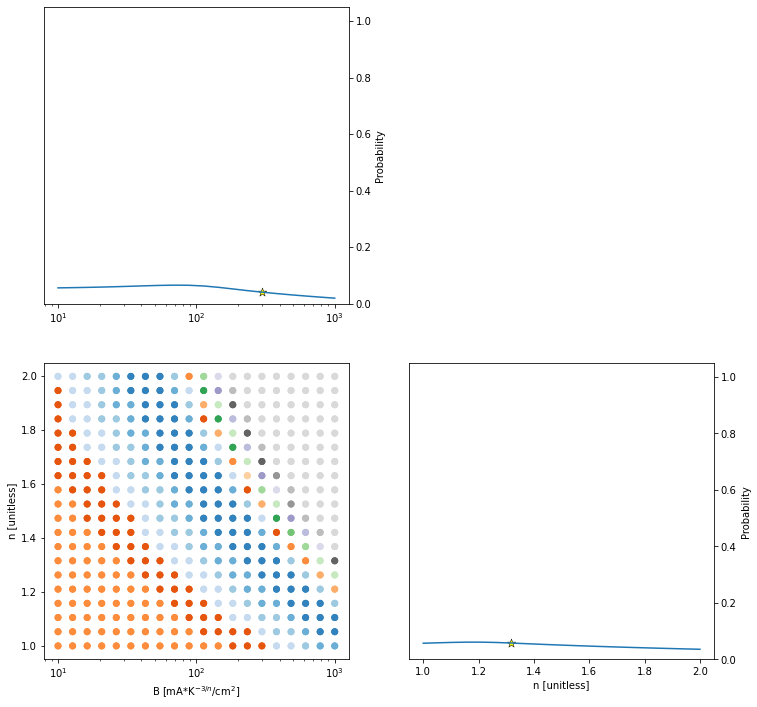

In [6]:
fig = plt.figure(figsize=(12, 12))
gs = GridSpec(nb_params, nb_params, figure=fig)

for i, param_range in enumerate(param_ranges):
    ax = fig.add_subplot(gs[i, i])

    # Marginal distributions of the individual parameters
    ax.plot(param_range, bpe.reset_index().groupby(params[i]).sum()['Posterior'])
    ax.scatter(best_fits.index[0][i], bpe.xs(best_fits.index[0][i], level=params[i])['Posterior'].sum(), s=80, marker='*', c='yellow', linewidths=0.5, edgecolors='black')
    if i == 0:
        ax.set_xscale('log')
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')
    ax.set_ylabel('Probability')
    ax.set_ylim([0, 1.05])
    if i == nb_params - 1:
        ax.set_xlabel(f'{labels[i]} [{units[i]}]')

    # Plot the relationship between any two parameters (conditional distributions)
    for pos in list(itertools.combinations(range(nb_params), 2)):
        x, y = pos[0], pos[1]
        ax = fig.add_subplot(gs[y, x])
        ax.set_xscale('log')
        coupled_ranges = [param_ranges[x], param_ranges[y]]
        levels = [params[x], params[y]]
        coupled_combs = list(itertools.product(*coupled_ranges))
        if x==0:
            ax.set_ylabel(f'{labels[y]} [{units[y]}]')
        if y==nb_params-1:
            ax.set_xlabel(f'{labels[x]} [{units[x]}]')
        x = [coupled_comb[0] for coupled_comb in coupled_combs]
        y = [coupled_comb[1] for coupled_comb in coupled_combs]

        sc = ax.scatter(x, y, c=[bpe.xs(coupled_comb, level=levels)['Posterior'].sum() for coupled_comb in coupled_combs], cmap='tab20c_r') #the dark blue region has the highest probability
        #tab20c_r is the reversed colormap (https://matplotlib.org/stable/tutorials/colors/colormaps.html)

Visualize the best fits @ 200K

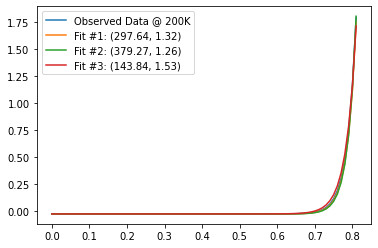

In [7]:
T = 200
fig, ax = plt.subplots()
v_obs = list(data[data['T']==T]['V'])[0]
ax.plot(v_obs, list(data[data['T']==T]['J'])[0], label=f'Observed Data @ {T}K')
for i, fit in enumerate(best_fits.index[:3]):
    i_fit = [compute_ID({'V':v,'T':T}, fit) for v in v_obs]
    ax.plot(v_obs, i_fit, label=f'Fit #{i+1}: {tuple(map(lambda x:round(x, 2), fit))}')
plt.legend()